In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv", usecols=["Age","Fare","Survived"])

In [49]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [50]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [51]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [52]:
X_train ,X_test ,y_train ,y_test =train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [54]:
X_train["Age_imputed"] = X_train["Age"]
X_test["Age_imputed"] = X_test["Age"]

In [55]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [56]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_74474/3090101260.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_74474/3090101260.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are sett

In [57]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


array([52.  , 29.  , 24.  , 21.  , 29.  , 34.  , 31.  , 70.5 , 16.  ,
       26.  , 45.  , 16.  , 34.  , 23.  ,  3.  , 18.  , 36.  , 64.  ,
       25.  , 31.  , 22.  , 24.  ,  9.  , 26.  , 40.  , 35.  , 29.  ,
       48.  , 38.  , 32.  , 31.  , 24.  , 19.  , 28.5 , 33.  , 36.  ,
       28.  , 32.  , 17.  , 25.  ,  9.  , 18.  , 23.  , 23.  ,  9.  ,
       25.  , 21.  , 36.  , 27.  , 26.  ,  3.  , 24.  , 18.  ,  4.  ,
        0.42, 30.  , 29.  , 52.  ,  7.  , 22.  , 35.  ,  0.83, 43.  ,
       45.  , 19.  , 31.  , 29.  , 22.  ,  4.  , 23.  , 25.  ,  5.  ,
       27.  , 30.  , 44.  , 20.  , 65.  , 16.  , 22.  , 27.  , 28.  ,
       32.  , 20.  , 40.  , 43.  , 47.  , 34.  , 41.  ,  1.  , 29.  ,
       24.  , 39.  , 23.  , 21.  , 35.  ,  4.  , 19.  , 24.  , 24.  ,
       28.  , 33.  , 28.5 , 34.  , 32.  , 56.  , 30.  , 30.  , 37.  ,
       54.  , 29.  , 28.  , 51.  ,  9.  , 34.  , 45.  , 46.  , 25.  ,
       31.  , 54.  , 45.5 , 31.  , 36.  , 30.  , 20.  , 51.  , 58.  ,
       19.  , 17.  ,

In [58]:
X_train['Age'].isnull().sum()


np.int64(148)

In [59]:
X_train


,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


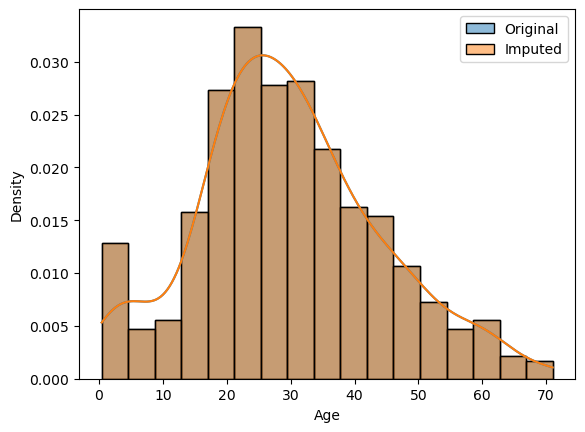

In [60]:
sns.histplot(X_train['Age'], label='Original', kde=True, stat='density')
sns.histplot(X_train['Age_imputed'], label='Imputed', kde=True, stat='density')

plt.legend()
plt.show()

In [61]:
print('Original variable variance: - random_imputation.ipynb:1', X_train['Age'].var())
print('Variance after random imputation: - random_imputation.ipynb:2', X_train['Age_imputed'].var())

Original variable variance: - random_imputation.ipynb:1 204.34951339046142
Variance after random imputation: - random_imputation.ipynb:2 204.34951339046142


In [62]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()


,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,71.512440
Age,71.512440,204.349513,204.349513
Age_imputed,71.512440,204.349513,204.349513


<Axes: >

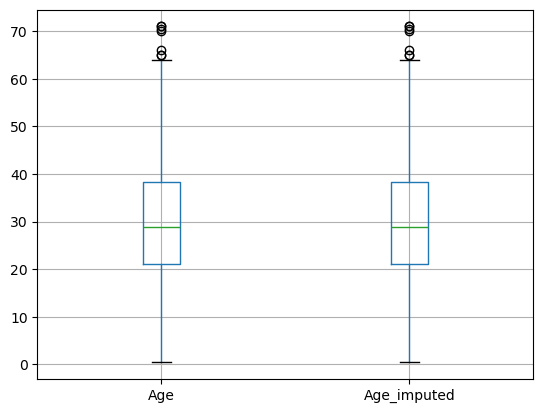

In [63]:
X_train[['Age', 'Age_imputed']].boxplot()


In [64]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=42).values[0]

In [67]:
data = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])


In [69]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [70]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [71]:
X = data
y = data['SalePrice']

In [72]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [73]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [74]:
X_train.sample(5)


,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
129,NaN,TA,150000,TA,NaN
138,TA,TA,230000,TA,TA
444,TA,TA,210000,TA,TA
338,NaN,TA,202500,TA,NaN
210,NaN,NaN,98000,NaN,NaN


In [75]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_74474/856878696.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp/ipykernel_74474/856878696.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate o

In [77]:

temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856
